# 08 — Retrieval success & error analysis by natural-product class

Do certain structural classes retrieve better than others, and when a method fails,
*what* does it wrongly rank first? We stratify the baseline ranked lists (from notebook
04) by the query's **NPClassifier** pathway, and characterise rank-1 errors by whether
the wrongly top-ranked compound shares the query's superclass.

Query annotations come from the cached NPClassifier results
(`data/cache/npclassifier_cache.json`); `scripts/exp_class_run.py` additionally classifies the
top-1 wrong candidate of every rank-1 miss (results cached in the same file), so the
error analysis has near-complete coverage without any live API calls here.

## 0 · Imports & load ranked lists + annotations

In [1]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

from dept_similarity.constants import RESULTS_DIR, PROCESSED_DATA_DIR, CACHE_DIR

FIG_DIR = Path(PROCESSED_DATA_DIR).parent / "figures"
DPI = 400
AMBER, SLATE, SAND, BROWN, GREY = "#D89168", "#4E6E81", "#B08968", "#6B3520", "#8A8A8A"
plt.rcParams.update({"font.size": 13, "axes.spines.top": False, "axes.spines.right": False})

METHODS = {"gauss_kernel_cosine": "Gaussian (Cosine)",
           "hungarian_match_cosine": "DEPT-Match (Cosine)",
           "ppm_bins_typed_cosine": "Shift binned (Cosine)"}
K_VALUES = (1, 10)

q = pd.read_parquet(f"{PROCESSED_DATA_DIR}/experimental_validation_set.parquet")
q["compound_id"] = q["compound_id"] + "_" + q["inchikey14"]
q_true14 = dict(zip(q["compound_id"], q["inchikey14"]))
npc = json.load(open(Path(CACHE_DIR) / "npclassifier_cache.json"))

def classes_of(ik14, level):
    r = npc.get(ik14)
    if r is None:
        return ["Unknown"]
    vals = r.get(f"{level}_results") or []
    return vals if vals else ["Unclassified"]

## 1 · Stratify hits by class and characterise rank-1 errors

For each method and query we record hit@1 / hit@10 against every NPClassifier label the
query carries, and — for rank-1 misses — whether the top-1 wrong hit shares the query's
superclass.

In [2]:
hit_rows, conf_rows = [], []
for md, label in METHODS.items():
    df = pd.read_parquet(Path(RESULTS_DIR) / md / "ranked_top10.parquet")
    for _, row in df.iterrows():
        qid = row["query_id"]; true14 = q_true14.get(qid)
        if true14 is None:
            continue
        cand14 = [ik[:14] if isinstance(ik, str) else None for ik in row["candidate_inchikey_list"]]
        hit_at = {k: (true14 in cand14[:k]) for k in K_VALUES}
        for level in ("pathway", "superclass"):
            for cls in classes_of(true14, level):
                for k in K_VALUES:
                    hit_rows.append({"method": label, "level": level, "class": cls,
                                     "k": k, "query_id": qid, "hit": int(hit_at[k])})
        if not hit_at[1] and cand14:
            top1 = cand14[0]
            q_sc = set(classes_of(true14, "superclass"))
            t_sc = set(classes_of(top1, "superclass")) if top1 in npc else None
            conf_rows.append({"method": label,
                              "same_superclass": (bool(q_sc & t_sc) if t_sc else None)})

hit_df = pd.DataFrame(hit_rows)
per_class = (hit_df.groupby(["method", "level", "class", "k"])
             .agg(n_queries=("query_id", "nunique"), hits=("hit", "sum")).reset_index())
per_class["hit_rate"] = 100.0 * per_class["hits"] / per_class["n_queries"]
conf_df = pd.DataFrame(conf_rows)

out = Path(RESULTS_DIR) / "class_analysis"; out.mkdir(parents=True, exist_ok=True)
per_class.to_parquet(out / "per_class_hits.parquet", index=False)
conf_df.to_parquet(out / "confusion.parquet", index=False)

per_class[(per_class.level == "pathway") & (per_class.k == 10)].pivot_table(
    index="class", columns="method", values="hit_rate").round(1)

method,DEPT-Match (Cosine),Gaussian (Cosine),Shift binned (Cosine)
class,,,
Alkaloids,79.2,83.3,65.3
Amino acids and Peptides,64.8,55.6,38.9
Carbohydrates,40.0,16.0,20.0
Fatty acids,68.0,88.0,72.0
Polyketides,91.3,87.0,69.6
Shikimates and Phenylpropanoids,62.7,76.7,54.7
Terpenoids,87.3,79.2,60.4
Unclassified,73.2,85.4,63.4


## 2 · Class-analysis figure — success by pathway & where the top-1 error lands

**a)** Hits@10 per NPClassifier pathway (grouped by method), sorted by mean success.
**b)** Composition of rank-1 errors: fraction landing in the *same* vs a *different*
superclass (or unclassified).

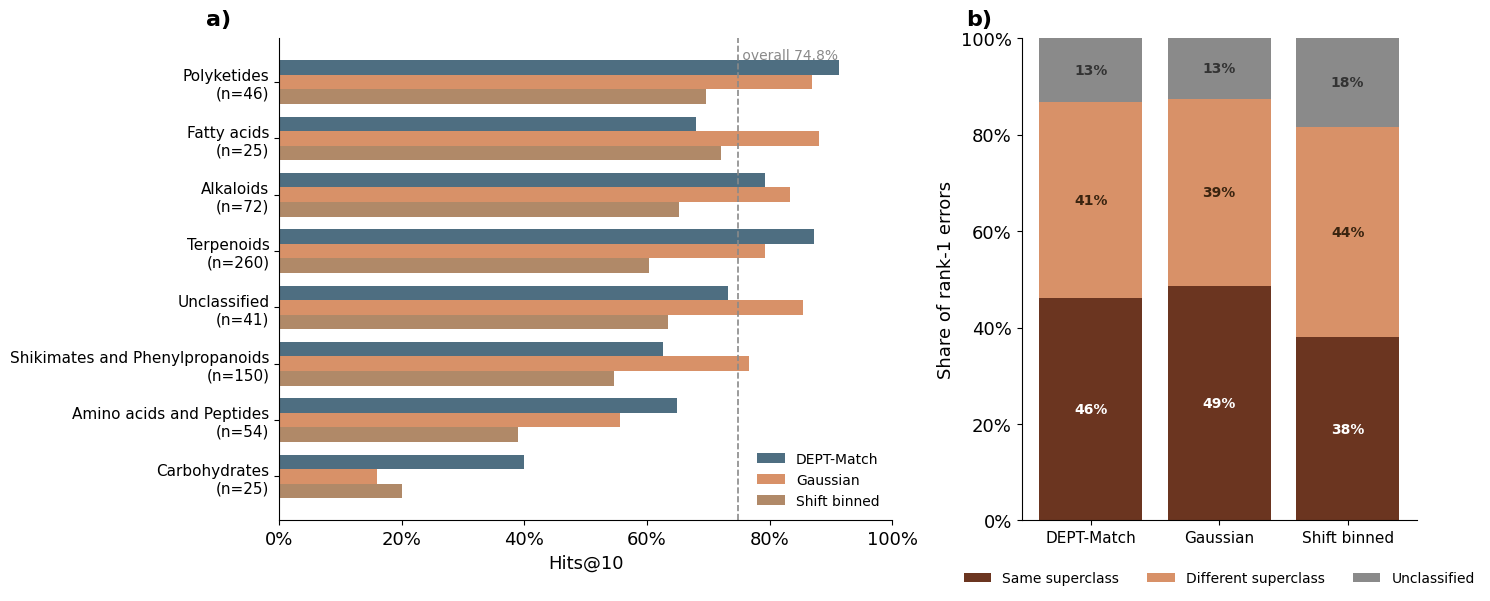

In [3]:
METHOD_STYLE = [("DEPT-Match (Cosine)", SLATE), ("Gaussian (Cosine)", AMBER), ("Shift binned (Cosine)", SAND)]

path10 = per_class[(per_class.level == "pathway") & (per_class.k == 10)]
piv = path10.pivot_table(index="class", columns="method", values="hit_rate")
nq = path10[path10.method == "Gaussian (Cosine)"].set_index("class")["n_queries"]
piv = piv.loc[piv.mean(axis=1).sort_values().index]

fig, axes = plt.subplots(1, 2, figsize=(15, 6.2), gridspec_kw={"width_ratios": [1.55, 1]})
ax = axes[0]; y = np.arange(len(piv)); h = 0.26
for i, (m, c) in enumerate(METHOD_STYLE):
    ax.barh(y + (1 - i) * h, piv[m].values, height=h, color=c, label=m.replace(" (Cosine)", ""))
ax.set_yticks(y); ax.set_yticklabels([f"{cls}\n(n={int(nq[cls])})" for cls in piv.index], fontsize=11)
ax.set_xlabel("Hits@10"); ax.set_xlim(0, 100)
ax.xaxis.set_major_formatter(mtick.PercentFormatter(xmax=100))
ax.axvline(74.8, color=GREY, ls="--", lw=1.2)
ax.text(74.8, len(piv) - 0.4, " overall 74.8%", color=GREY, fontsize=10, va="top")
ax.text(-0.12, 1.06, "a)", transform=ax.transAxes, fontsize=16, fontweight="bold", va="top", ha="left")
ax.legend(frameon=False, fontsize=10, loc="lower right")

ax = axes[1]; methods = [m for m, _ in METHOD_STYLE]
same, cross, unk = [], [], []
for m in methods:
    s = conf_df[conf_df.method == m]; n = len(s)
    same.append(100*(s.same_superclass == True).sum()/n)
    cross.append(100*(s.same_superclass == False).sum()/n)
    unk.append(100*s.same_superclass.isna().sum()/n)
same, cross, unk = np.array(same), np.array(cross), np.array(unk)
x = np.arange(len(methods))
ax.bar(x, same, color=BROWN, label="Same superclass")
ax.bar(x, cross, bottom=same, color=AMBER, label="Different superclass")
ax.bar(x, unk, bottom=same + cross, color=GREY, label="Unclassified")
for seg, bottom, tc in ((same, np.zeros_like(same), "white"), (cross, same, "#3A2410"), (unk, same + cross, "#333333")):
    for xi, val, b in zip(x, seg, bottom):
        ax.text(xi, b + val/2, f"{val:.0f}%", ha="center", va="center", color=tc, fontsize=10, fontweight="bold")
ax.set_xticks(x); ax.set_xticklabels([m.replace(" (Cosine)", "") for m in methods], fontsize=11)
ax.set_ylabel("Share of rank-1 errors"); ax.set_ylim(0, 100)
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=100))
ax.text(-0.14, 1.06, "b)", transform=ax.transAxes, fontsize=16, fontweight="bold", va="top", ha="left")
ax.legend(frameon=False, fontsize=10, loc="upper center", bbox_to_anchor=(0.5, -0.08), ncol=3)

fig.tight_layout()
fig.savefig(FIG_DIR / "class_analysis.png", dpi=DPI, bbox_inches="tight")
plt.show()